/tmp/ipykernel_4095733/868619194.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


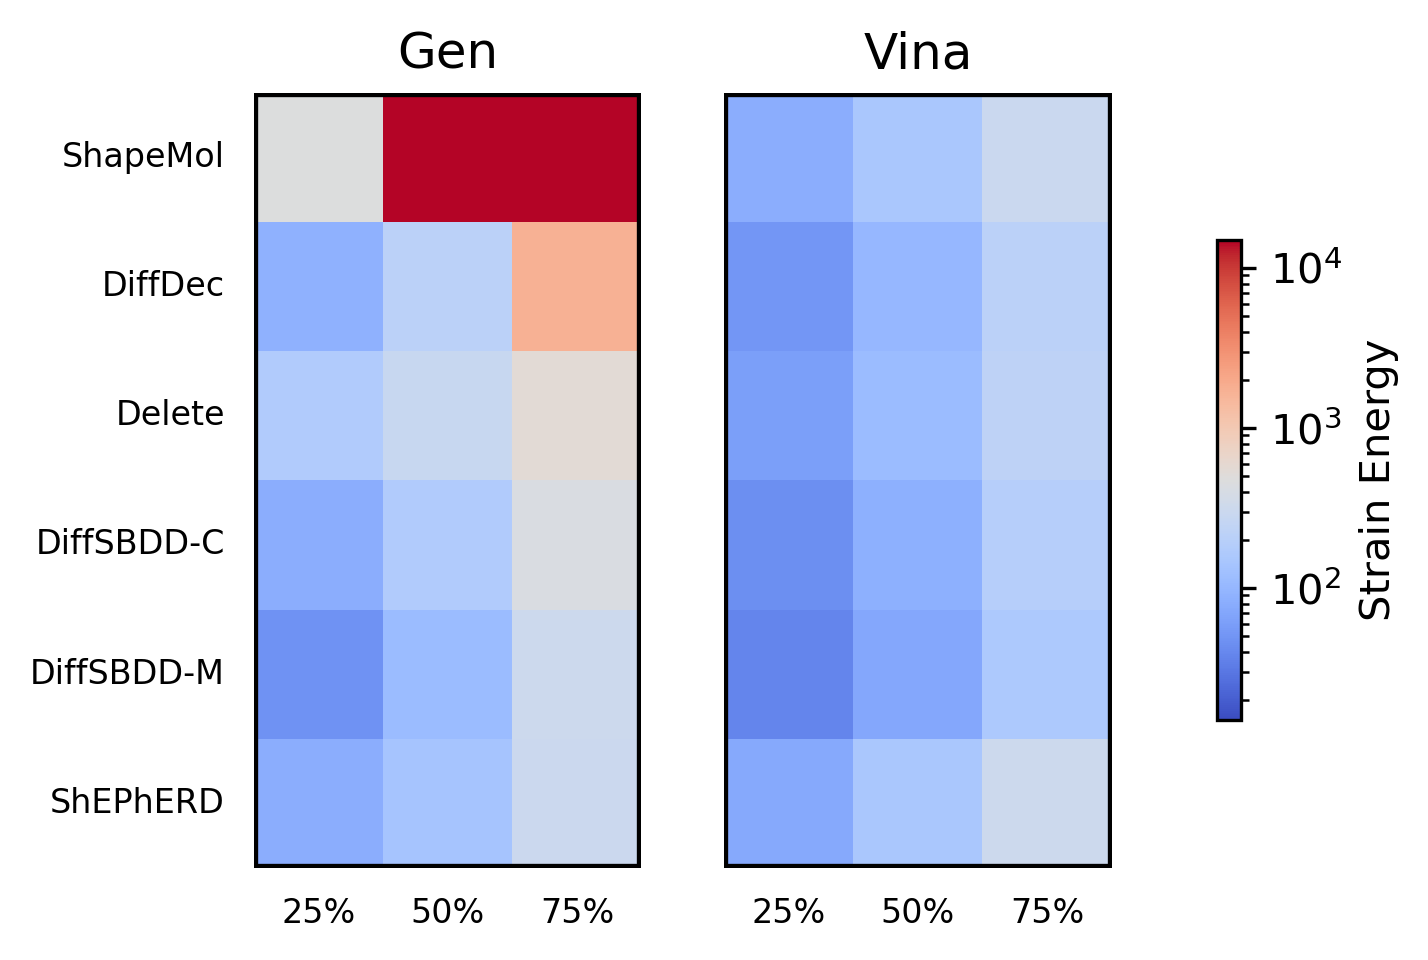

/tmp/ipykernel_4095733/868619194.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


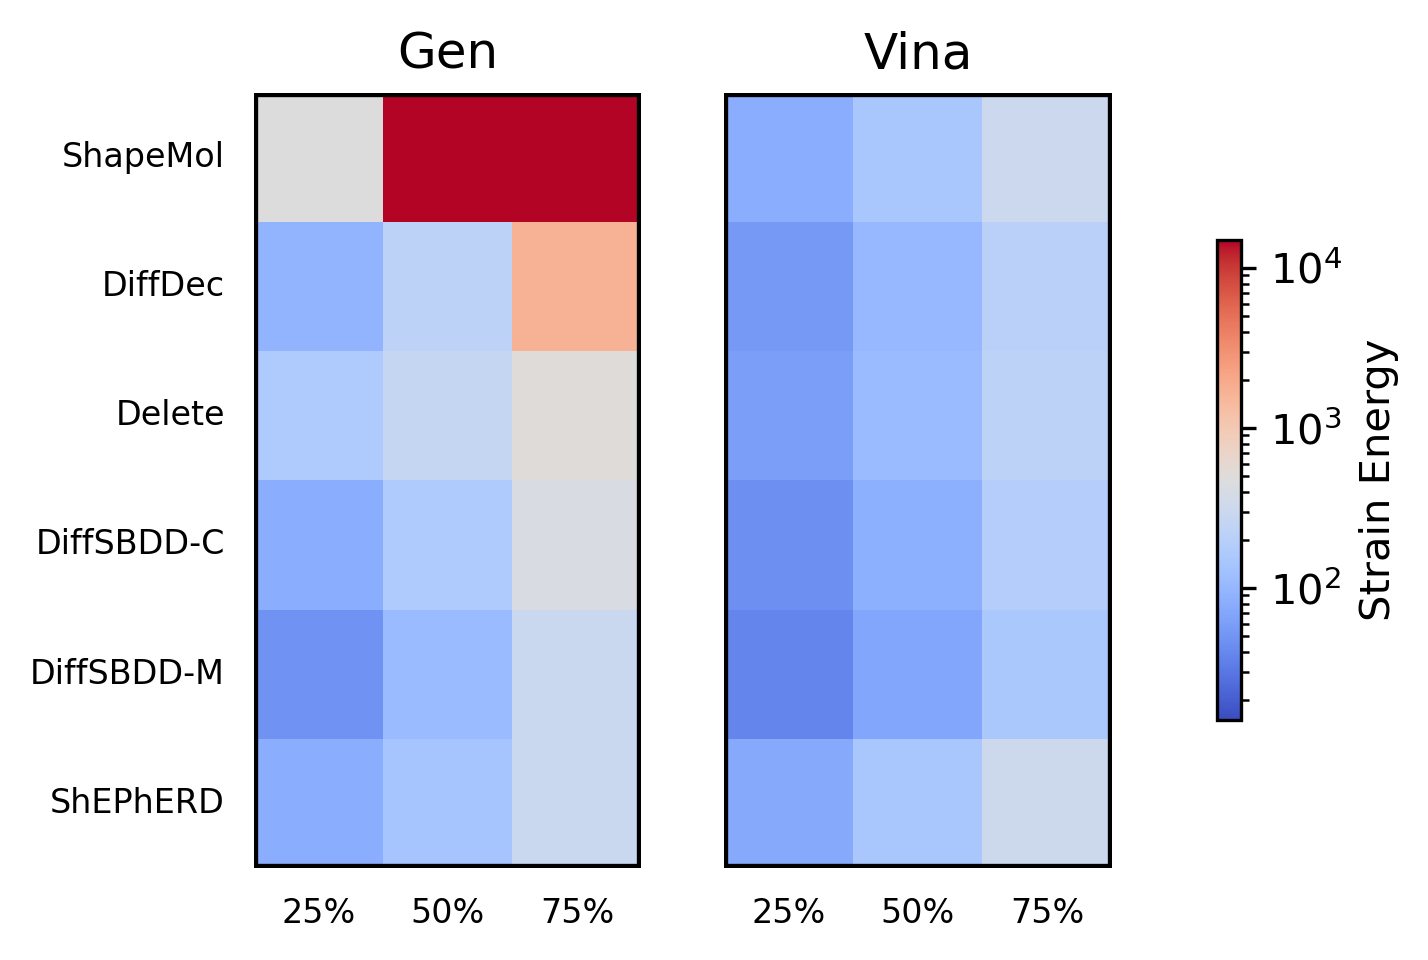

/tmp/ipykernel_4095733/868619194.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


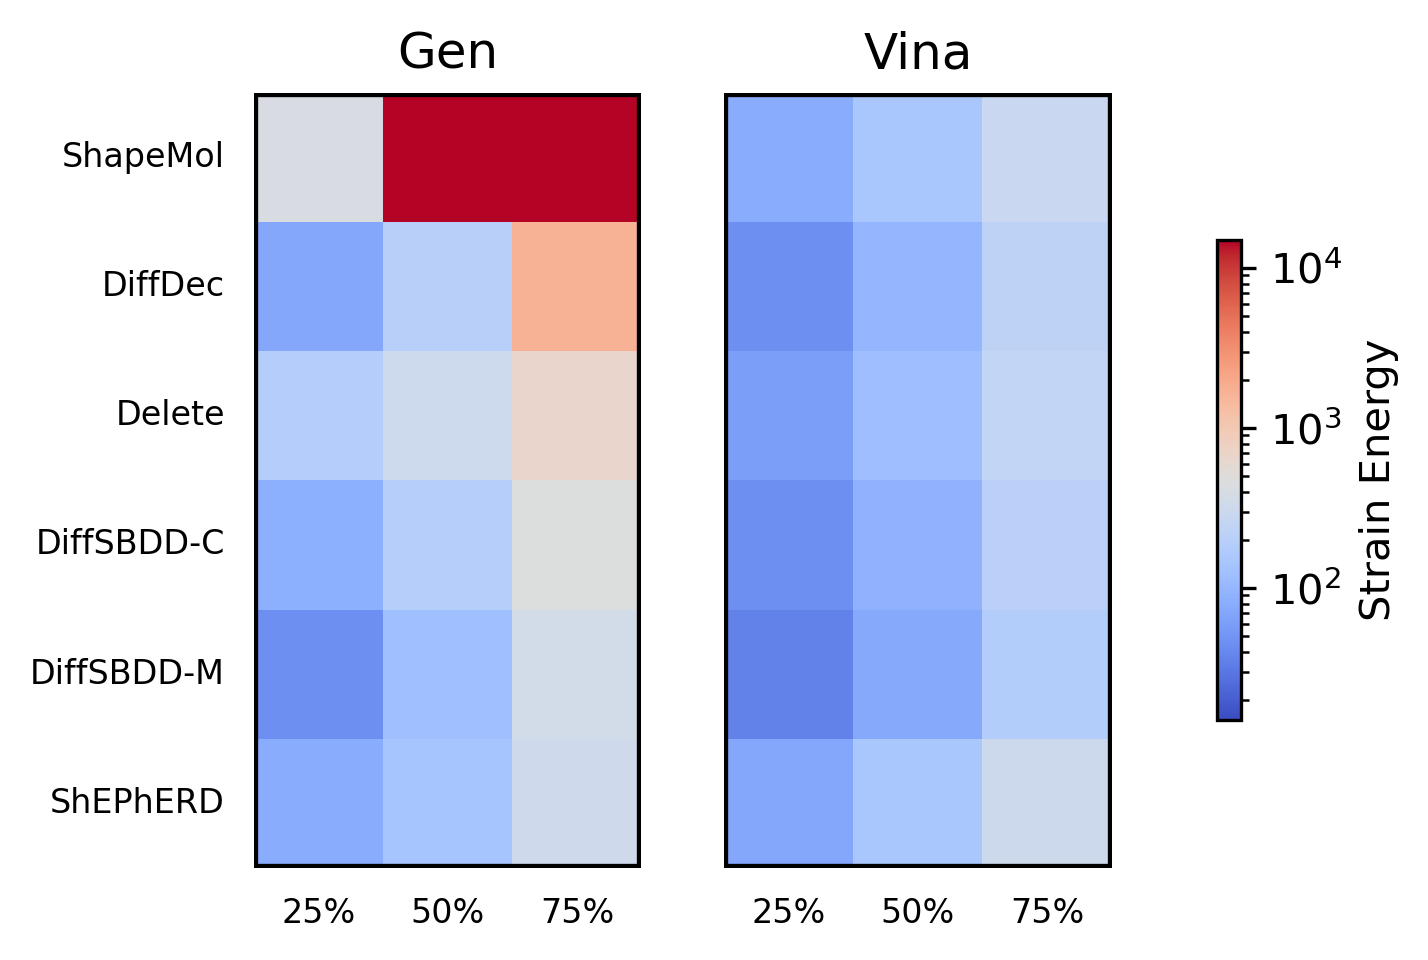

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LogNorm


# ========== 数据读取 ==========
data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"

round_list = ["Round1", "Round2", "Round3"]

# ========== Hit2Lead 配置 ==========
TASK_LIST_H2L = [
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    "ShapeMol_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "DiffSBDD-C",
    "diffSBDD_cond_moad_Hit_to_Lead": "DiffSBDD-M",
    "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "ShEPhERD",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "Delete",
}


# ========== 读取 Hit2Lead 数据 ==========
results_all = []
results_seen = []
results_unseen = []

for round_name in round_list:
    for task in TASK_LIST_H2L:
        yaml_path = os.path.join(data_path, round_name, "Hit_to_Lead_Results", task, "results.yaml")
        if not os.path.exists(yaml_path):
            print(f"Warning: {yaml_path} not found")
            continue
            
        with open(yaml_path, 'r') as f:
            result = yaml.safe_load(f)

            results_all.append({
                "Model": H2L_NAME_MAPPING[task],
                "Round": round_name,
                "gen_25": result['metrics']['StrainEnergy']['all']['StrainEnergy25%'],
                "gen_50": result['metrics']['StrainEnergy']['all']['StrainEnergy50%'],
                "gen_75": result['metrics']['StrainEnergy']['all']['StrainEnergy75%'],
                "vina_25": result['metrics']['StrainEnergy_docked']['all']['StrainEnergy25%'],
                "vina_50": result['metrics']['StrainEnergy_docked']['all']['StrainEnergy50%'],
                "vina_75": result['metrics']['StrainEnergy_docked']['all']['StrainEnergy75%'],
            })
            
            results_seen.append({
                "Model": H2L_NAME_MAPPING[task],
                "Round": round_name,
                "gen_25": result['metrics']['StrainEnergy']['seen']['StrainEnergy25%'],
                "gen_50": result['metrics']['StrainEnergy']['seen']['StrainEnergy50%'],
                "gen_75": result['metrics']['StrainEnergy']['seen']['StrainEnergy75%'],
                "vina_25": result['metrics']['StrainEnergy_docked']['seen']['StrainEnergy25%'],
                "vina_50": result['metrics']['StrainEnergy_docked']['seen']['StrainEnergy50%'],
                "vina_75": result['metrics']['StrainEnergy_docked']['seen']['StrainEnergy75%'],
            })
            
            results_unseen.append({
                "Model": H2L_NAME_MAPPING[task],
                "Round": round_name,
                "gen_25": result['metrics']['StrainEnergy']['unseen']['StrainEnergy25%'],
                "gen_50": result['metrics']['StrainEnergy']['unseen']['StrainEnergy50%'],
                "gen_75": result['metrics']['StrainEnergy']['unseen']['StrainEnergy75%'],
                "vina_25": result['metrics']['StrainEnergy_docked']['unseen']['StrainEnergy25%'],
                "vina_50": result['metrics']['StrainEnergy_docked']['unseen']['StrainEnergy50%'],
                "vina_75": result['metrics']['StrainEnergy_docked']['unseen']['StrainEnergy75%'],
            })

df_results_all = pd.DataFrame(results_all)
df_results_seen = pd.DataFrame(results_seen)
df_results_unseen = pd.DataFrame(results_unseen)


# ========== 聚合数据 ==========
all_key = ["gen_25", "gen_50", "gen_75", "vina_25", "vina_50", "vina_75"]

df_mean_all = df_results_all.groupby("Model", as_index=False)[all_key].mean()
df_mean_seen = df_results_seen.groupby("Model", as_index=False)[all_key].mean()
df_mean_unseen = df_results_unseen.groupby("Model", as_index=False)[all_key].mean()


# ========== 数据转换函数 ==========
def prepare_heatmap_data(df_mean):
    """
    将 df_mean 转换为绘图所需的格式
    """
    result_df = df_mean.rename(columns={
        "Model": "Models",
        "gen_25": "gen_mean_25",
        "gen_50": "gen_mean_50",
        "gen_75": "gen_mean_75",
        "vina_25": "vina_mean_25",
        "vina_50": "vina_mean_50",
        "vina_75": "vina_mean_75",
    })
    
    result_df = result_df.sort_values("gen_mean_75", ascending=False).reset_index(drop=True)
    
    return result_df


# ========== 绘图函数 ==========
def plot_strain_heatmap(result_df, save_file, vmin=15, vmax=15000):
    """
    绘制 Strain Energy 热力图
    """
    heatmap_data_gen = []
    heatmap_data_vina = []

    for metric in ["25", "50", "75"]:
        for condition in ["gen_mean", "vina_mean"]:
            col_name = f"{condition}_{metric}"
            values = result_df[col_name].tolist()
            if condition == "gen_mean":
                heatmap_data_gen.append(values)
            elif condition == "vina_mean":
                heatmap_data_vina.append(values)

    xticklabels_with_gaps = ["25%", "50%", "75%"]

    def add_gaps(heatmap_data):
        heatmap_data_with_gaps = []
        for i in range(0, len(heatmap_data), 3):
            heatmap_data_with_gaps.append(heatmap_data[i])
            heatmap_data_with_gaps.append(heatmap_data[i+1])
            heatmap_data_with_gaps.append(heatmap_data[i+2])
        return np.array(heatmap_data_with_gaps).T

    heatmap_data_gen_with_gaps = add_gaps(heatmap_data_gen)
    heatmap_data_vina_with_gaps = add_gaps(heatmap_data_vina)

    # 根据模型数量调整图片高度
    n_models = len(result_df)
    fig_height = max(3, n_models * 0.55)
    
    fig, axes = plt.subplots(1, 2, figsize=(4, fig_height), dpi=300)

    norm = LogNorm(vmin=vmin, vmax=vmax)

    # gen
    sns.heatmap(
        heatmap_data_gen_with_gaps,
        cmap="coolwarm",
        xticklabels=xticklabels_with_gaps,
        yticklabels=result_df["Models"],
        cbar=False,
        square=True,
        ax=axes[0],
        norm=norm
    )
    axes[0].set_title("Gen")
    axes[0].add_patch(
        patches.Rectangle(
            (0, 0), 3, n_models,
            transform=axes[0].transData,
            color="black", fill=False, linewidth=2
        )
    )

    # vina
    sns.heatmap(
        heatmap_data_vina_with_gaps,
        cmap="coolwarm",
        xticklabels=xticklabels_with_gaps,
        yticklabels=[],
        cbar=False,
        square=True,
        ax=axes[1],
        norm=norm
    )
    axes[1].set_title("Vina")
    axes[1].add_patch(
        patches.Rectangle(
            (0, 0), 3, n_models,
            transform=axes[1].transData,
            color="black", fill=False, linewidth=2
        )
    )

    cbar = fig.colorbar(axes[0].collections[0], ax=axes, orientation='vertical', fraction=0.03, pad=0.08)
    cbar.set_label("Strain Energy")
    cbar.ax.set_position([1.05, 0.15, 0.02, 0.7])

    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False)

    for ax in axes:
        plt.sca(ax)
        plt.yticks(fontsize=8)
        plt.xticks(fontsize=8)

    plt.tight_layout()
    plt.savefig(save_file, bbox_inches='tight', format='svg')
    plt.show()
    plt.close()


# ========== 调用绑图 ==========
save_dir = "./final_plot/output"
os.makedirs(save_dir, exist_ok=True)

# All proteins
result_df_all = prepare_heatmap_data(df_mean_all)
plot_strain_heatmap(result_df_all, os.path.join(save_dir, "06-strain_heatmap_hit2lead_all.svg"))

# Seen proteins
result_df_seen = prepare_heatmap_data(df_mean_seen)
plot_strain_heatmap(result_df_seen, os.path.join(save_dir, "06-strain_heatmap_hit2lead_seen.svg"))

# Unseen proteins
result_df_unseen = prepare_heatmap_data(df_mean_unseen)
plot_strain_heatmap(result_df_unseen, os.path.join(save_dir, "06-strain_heatmap_hit2lead_unseen.svg"))